# Classic Supervised Learning Algorithms

## Learning Objectives
- Understand key classical supervised algorithms and their use cases.
- Learn basic ideas behind Decision Trees, k-NN, SVM, Naive Bayes, and Softmax Regression.

## Introduction
Classic supervised algorithms form the foundation of traditional machine learning. Each has strengths suitable for different problem characteristics.

## Core Concepts
- **Decision Trees:** Tree-like models splitting data by feature values.
- **k-Nearest Neighbors (k-NN):** Instance-based learning using closest data points.
- **Support Vector Machines (SVM):** Find hyperplanes to separate classes with maximum margin.
- **Naive Bayes:** Probabilistic classifier assuming feature independence.
- **Softmax Regression:** Multinomial generalization of logistic regression.

## Example
Train a Decision Tree on Iris dataset.

A Decision tree is a type of supervised learning technique that can be used for classification as well as regression. It continuously splits data into smaller segments by a parameter. It uses an if-else structure with some form of probability to make predictions.

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



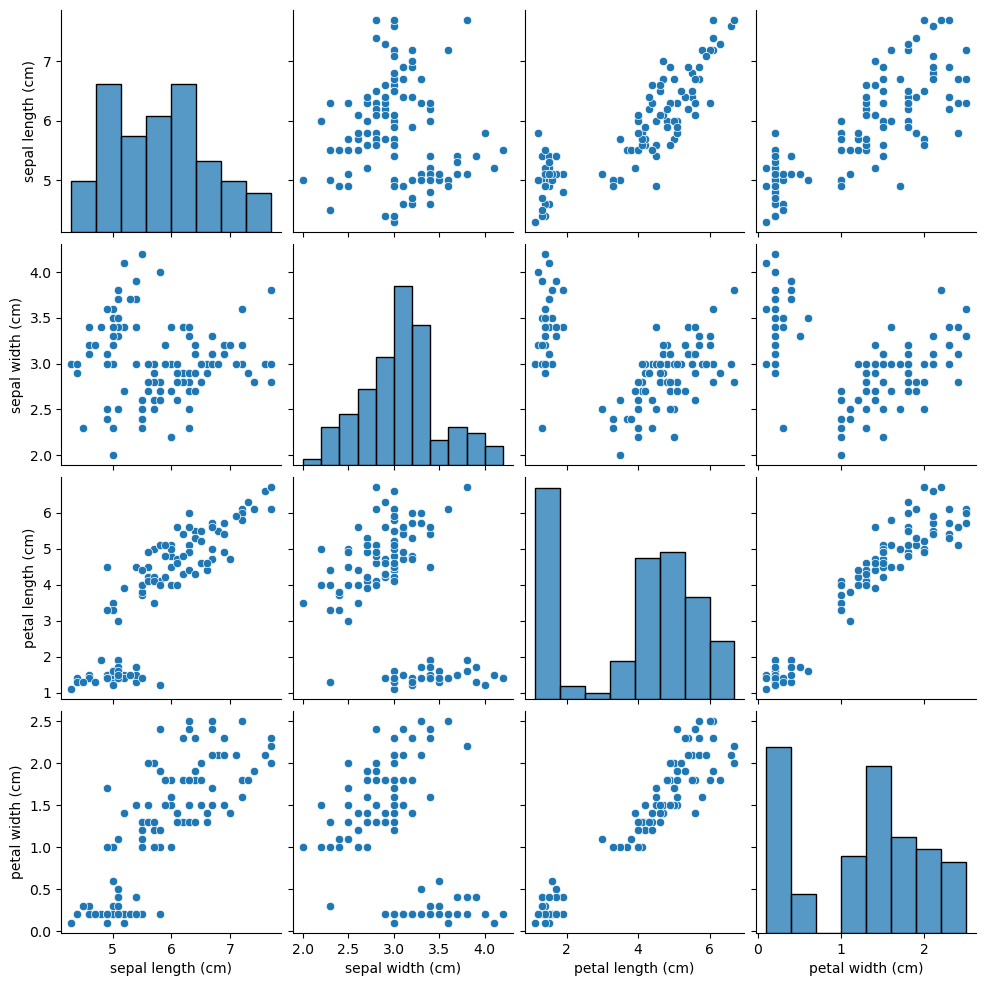

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import classification_report
import seaborn as sns
import pandas as pd

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=42)

df = pd.DataFrame(X_train, columns=iris.feature_names)
df.head(5)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print(classification_report(y_test, y_pred, target_names=iris.target_names))
sns.pairplot(df)

K-Nearest Neighbours (KNN)

This is a simple algorithm that stores all the available cases and classifies the new data or case based on a similarity measure. It is mostly used to classifies a data point based on how its neighbours are classified

KNN Classification Results:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



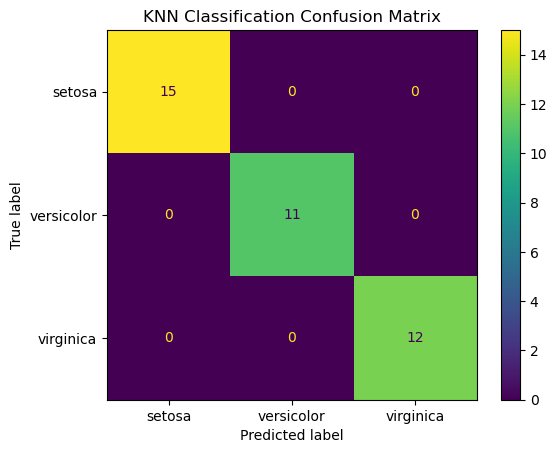

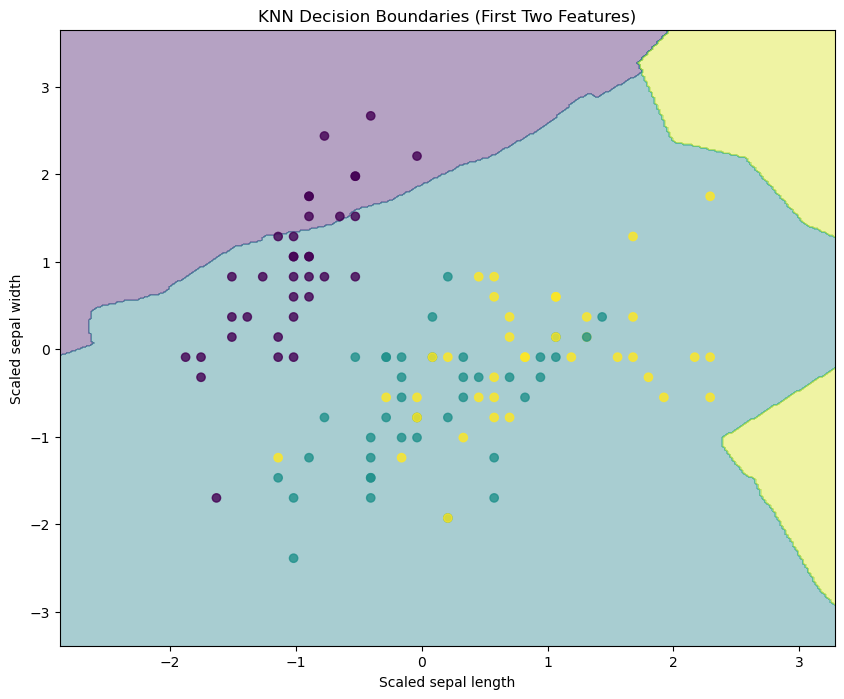

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

# Evaluate model
print("KNN Classification Results:")
print(classification_report(y_test, knn_pred, target_names=iris.target_names))

# Plot confusion matrix
cm = confusion_matrix(y_test, knn_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title('KNN Classification Confusion Matrix')
plt.show()

# Visualization of decision boundaries (using first two features)
plt.figure(figsize=(10, 8))
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel(), np.zeros_like(xx.ravel()), np.zeros_like(xx.ravel())])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
scatter = plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, alpha=0.8)
plt.xlabel('Scaled sepal length')
plt.ylabel('Scaled sepal width')
plt.title('KNN Decision Boundaries (First Two Features)')
plt.show()

Support Vector Machines

SVMs are supervised learning algorithms that can perform both classification and regression tasks very efficiently. It finds a hyperplane that best separates classes in feature space and also brings to the table the flexibility of defining how much error is acceptable.

SVM Classification Results:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



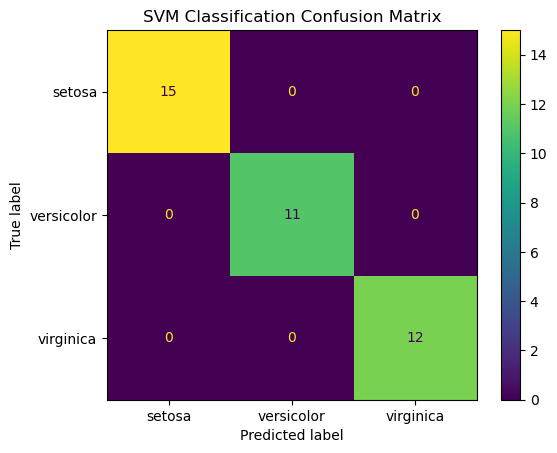

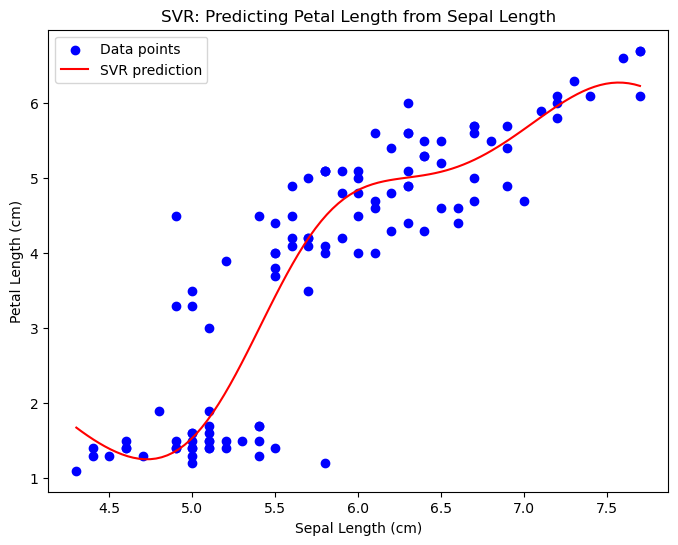


SVM Regression Results:
Mean Squared Error: 0.6361
R² Score: 0.7868


In [4]:
from sklearn.svm import SVC, SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# SVM Classification
# Scale the features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVC model
svc = SVC(kernel='rbf')
svc.fit(X_train_scaled, y_train)
svc_pred = svc.predict(X_test_scaled)

# Calculate and display classification metrics
print("SVM Classification Results:")
print(classification_report(y_test, svc_pred, target_names=iris.target_names))

# Plot confusion matrix
cm = confusion_matrix(y_test, svc_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title('SVM Classification Confusion Matrix')
plt.show()

# SVM Regression example (using one feature to predict another)
# Let's predict petal length using sepal length
X_reg = X_train[:, 0].reshape(-1, 1)  # sepal length
y_reg = X_train[:, 2]  # petal length

# Train SVR model
svr = SVR(kernel='rbf')
svr.fit(X_reg, y_reg)

# Plotting regression results
plt.figure(figsize=(8, 6))
plt.scatter(X_reg, y_reg, color='blue', label='Data points')
X_plot = np.linspace(X_reg.min(), X_reg.max(), 100).reshape(-1, 1)
y_plot = svr.predict(X_plot)
plt.plot(X_plot, y_plot, color='red', label='SVR prediction')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.title('SVR: Predicting Petal Length from Sepal Length')
plt.legend()
plt.show()

# Print regression metrics
y_reg_pred = svr.predict(X_reg)
mse = np.mean((y_reg - y_reg_pred) ** 2)
r2 = svr.score(X_reg, y_reg)
print("\nSVM Regression Results:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Naive Baye's

Naive Bayes Classification Results:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



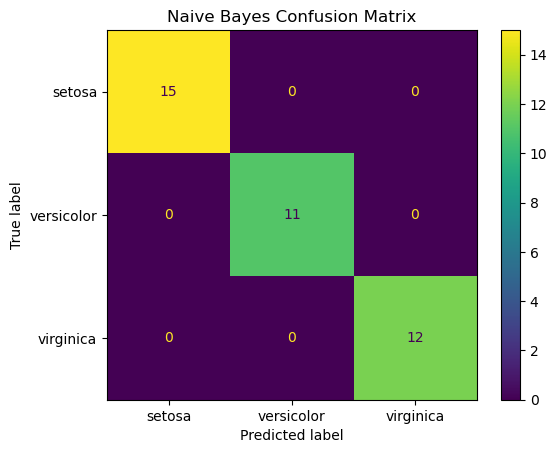

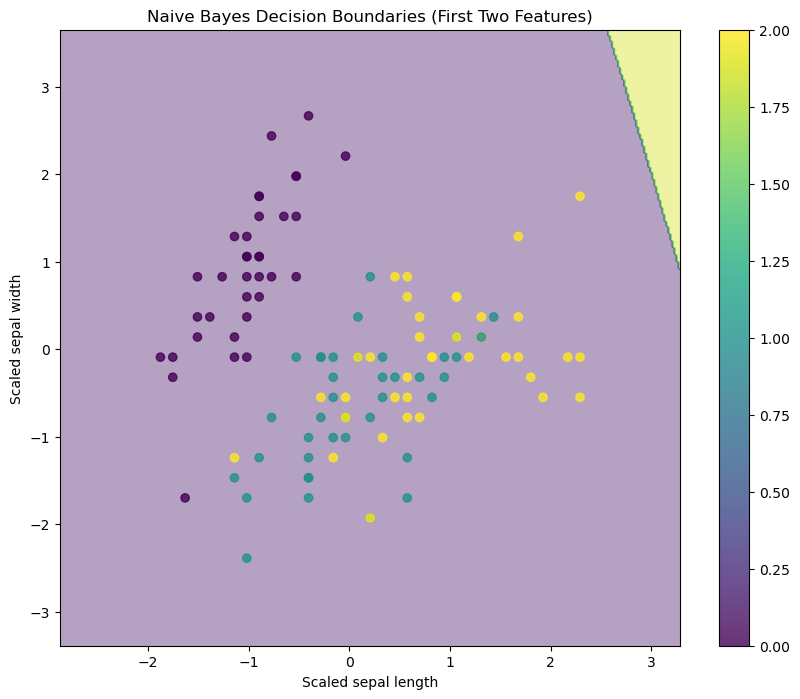


Probabilities for first test sample:
setosa: 0.000
versicolor: 0.995
virginica: 0.005


In [12]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np

import matplotlib.pyplot as plt

# Train Naive Bayes model
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
nb_pred = nb.predict(X_test_scaled)

# Print classification report
print("Naive Bayes Classification Results:")
print(classification_report(y_test, nb_pred, target_names=iris.target_names))

# Plot confusion matrix
cm = confusion_matrix(y_test, nb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title('Naive Bayes Confusion Matrix')
plt.show()

# Visualization of decision boundaries (using first two features)
plt.figure(figsize=(10, 8))
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = nb.predict(np.c_[xx.ravel(), yy.ravel(), np.zeros_like(xx.ravel()), np.zeros_like(xx.ravel())])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
scatter = plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, alpha=0.8)
plt.xlabel('Scaled sepal length')
plt.ylabel('Scaled sepal width')
plt.title('Naive Bayes Decision Boundaries (First Two Features)')
plt.colorbar(scatter)
plt.show()

# Model probabilities for a sample prediction
sample_probs = nb.predict_proba(X_test_scaled[0:1])
print("\nProbabilities for first test sample:")
for class_name, prob in zip(iris.target_names, sample_probs[0]):
    print(f"{class_name}: {prob:.3f}")

Softmax Regression

Softmax Regression Classification Results:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



/Users/johnmoses/miniforge3/envs/mforge312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


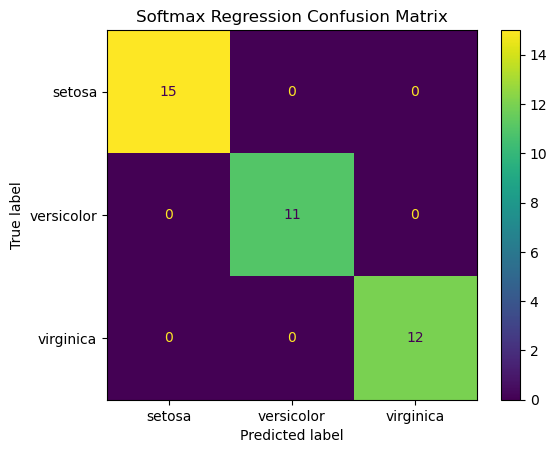

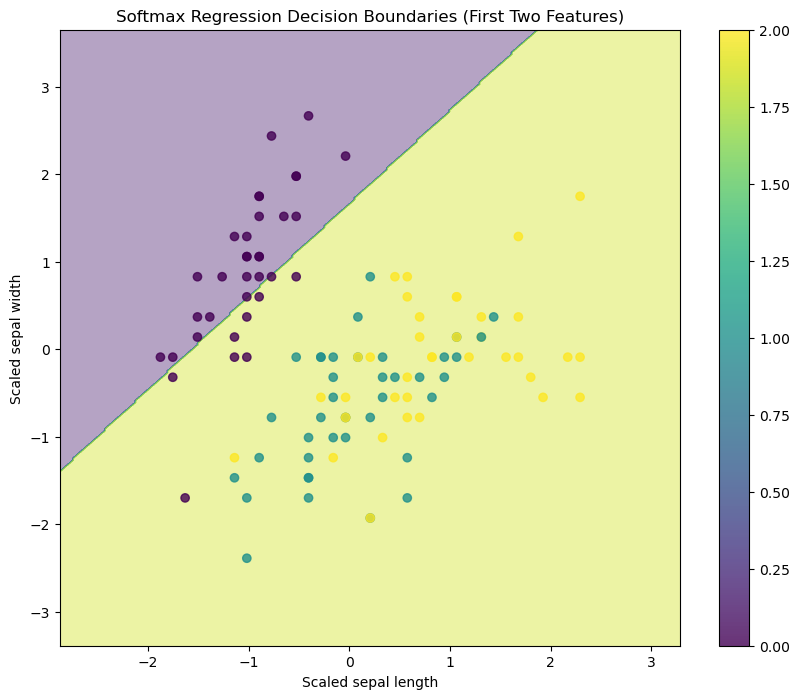


Probabilities for first test sample:
setosa: 0.012
versicolor: 0.870
virginica: 0.118


In [13]:
from sklearn.linear_model import LogisticRegression
import numpy as np

import matplotlib.pyplot as plt

# Train Softmax Regression model (LogisticRegression with 'multinomial' setting)
softmax = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
softmax.fit(X_train_scaled, y_train)
softmax_pred = softmax.predict(X_test_scaled)

# Print classification report
print("Softmax Regression Classification Results:")
print(classification_report(y_test, softmax_pred, target_names=iris.target_names))

# Plot confusion matrix
cm = confusion_matrix(y_test, softmax_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title('Softmax Regression Confusion Matrix')
plt.show()

# Visualization of decision boundaries (using first two features)
plt.figure(figsize=(10, 8))
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = softmax.predict(np.c_[xx.ravel(), yy.ravel(), np.zeros_like(xx.ravel()), np.zeros_like(xx.ravel())])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
scatter = plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, alpha=0.8)
plt.xlabel('Scaled sepal length')
plt.ylabel('Scaled sepal width')
plt.title('Softmax Regression Decision Boundaries (First Two Features)')
plt.colorbar(scatter)
plt.show()

# Example inference with probability scores
sample_idx = 0
sample_probs = softmax.predict_proba(X_test_scaled[sample_idx:sample_idx+1])
print("\nProbabilities for first test sample:")
for class_name, prob in zip(iris.target_names, sample_probs[0]):
    print(f"{class_name}: {prob:.3f}")

## Exercise
Try training a k-NN classifier on the same dataset and compare results.

In [ ]:
# Your code here

## Summary
- Classic algorithms remain useful and interpretable.
- Each algorithm has strengths depending on data characteristics.


## Further Reading
- [Scikit-learn Classifiers](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning)
- [Introduction to Machine Learning](https://www.coursera.org/learn/machine-learning) by Andrew Ng
